In [1]:
import Gmsh: gmsh
using Gridap, GridapGmsh
using Plots

In [2]:
function create_square_model(h)
    gmsh.initialize()
    gmsh.model.add("unit_square");
    gmsh.model.geo.addPoint(0.0, 0.0, 0.0, h, 1); # last argument is optional identifier, unique per dimension
    gmsh.model.geo.addPoint(1.0, 0.0, 0.0, h, 2);
    gmsh.model.geo.addPoint(1.0, 1.0, 0.0, h, 3);
    gmsh.model.geo.addPoint(0.0, 1.0, 0.0, h, 4);
    gmsh.model.geo.addLine(1, 2, 1); 
    gmsh.model.geo.addLine(2, 3, 2); # line 2 goes from point 2 to point 3
    gmsh.model.geo.addLine(3, 4, 3);
    gmsh.model.geo.addLine(4, 1, 4);
    
    gmsh.model.geo.addCurveLoop([1, 2, 3, 4], 1);

    gmsh.model.geo.addPlaneSurface([1], 1);

    gmsh.model.geo.synchronize();

    # Define physical groups without the string argument
    edges_tag = gmsh.model.addPhysicalGroup(1, [1, 2, 3, 4])   # edges
    corners_tag = gmsh.model.addPhysicalGroup(0, [1, 2, 3, 4]) # corners
    domain_tag = gmsh.model.addPhysicalGroup(2, [1])           # surface
    
    # Set names for the physical groups
    gmsh.model.setPhysicalName(1, edges_tag, "boundary")
    gmsh.model.setPhysicalName(0, corners_tag, "boundary")
    gmsh.model.setPhysicalName(2, domain_tag, "domain")

    gmsh.model.mesh.generate(2); # dimension is 2
    
    model = GmshDiscreteModel(gmsh);
    gmsh.finalize();
    return model
end

create_square_model (generic function with 1 method)

In [3]:
function error_estimates(n,h)
    model = create_square_model(h) # fix above function above using the tutorial
    order = 1
    reffe = ReferenceFE(lagrangian, Float64, order)
    V = TestFESpace(model, reffe, conformity=:H1, dirichlet_tags="boundary")
    U = TrialFESpace(V, 0.0)

    Ω = Triangulation(model)
    dΩ = Measure(Ω, 2 * order)

    Δt, T = 2.0^(-n), 1.0 # time step, final time
    a0 = 0.05 # diffusion coefficient
    num_steps = Int(T / Δt)

    f(t, x) = sin(π * x[1]) * sin(2 * π * x[2]) * (5 * a0 * π^2 * (2 - cos(t)) + sin(t))
    f(t) = x -> f(t,x)

    u_exact(t, x) = sin(pi * x[1]) * sin(2pi * x[2]) * (2 - cos(t)) # fill in the rests
    u₀ = x -> sin(pi * x[1]) * sin(2pi * x[2]) # fill in initial condition based on u_exact

    # assemble the left hand side:
    a(u, v) = ∫( (1/Δt) * u * v + a0 * (∇(u) ⋅ ∇(v)) )dΩ   # fill in the rest
    aa = assemble_matrix(a, U, V)

    uh = interpolate_everywhere(u₀, U) # initial condition

    max_el2 = 0.0

    for n in 1:num_steps # start time-stepping
        tₙ = n * Δt
        tₙ₋₁ = (n-1) * Δt

        # assemble the right hand side
        b(v) = ∫( (1/Δt)*uh*v + f(tₙ)*v )dΩ  # fill in the rest
        bb = assemble_vector(b, V)
        uh = FEFunction(U, aa \ bb) # solve for next value

        u_exact_n = x -> u_exact(tₙ, x)

        e = u_exact_n - uh
        el2 = sqrt(sum( ∫( e*e )*dΩ )) # fill in the rest

        max_el2 = max(max_el2, el2)
    end

    return max_el2
end

error_estimates (generic function with 1 method)

In [4]:
hs1 = 0.05
hs2 = 0.01

errors_h1 = [error_estimates(n, hs1) for n in 1:10]
errors_h2 = [error_estimates(n, hs2) for n in 1:10]


Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.000404069s, CPU 0.000368s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0081545s, CPU 0.008135s)
Info    : 513 nodes 1028 elements
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.000142849s, CPU 0.000144s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00659267s, CPU 0.006578s)
Info    : 513 nodes 1028 elements
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshin

10-element Vector{Float64}:
 0.030230977532327206
 0.016498710454444745
 0.008589223437768594
 0.004327838487012449
 0.0021104318864024582
 0.0009796181250944051
 0.00041079254931928314
 0.00015807103663478185
 0.000160767177754735
 0.00016144633335754124

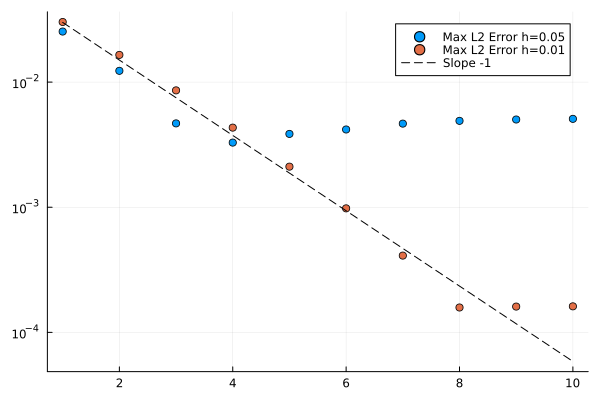

In [5]:
C = 6e-2 # chosen to have errors and line match up
reference_slope = -1
reference_line = C * 2.0 .^ (reference_slope * (1:10))
plot(1:10, errors_h1, seriestype=:scatter, yscale=:log10, label="Max L2 Error h=0.05")
plot!(1:10, errors_h2, seriestype=:scatter, yscale=:log10, label="Max L2 Error h=0.01")
plot!(1:10, reference_line, label="Slope -1", linestyle=:dash, color=:black)